# Module Lab: Build a Simple Rock Type Classifier

## Scenario

You are part of a **mining analytics and geology support team** exploring how computer vision could assist with rapid rock image classification.

In a real mining environment, image-based classification could support workflows such as:

- preliminary ore and waste rock screening
- conveyor belt monitoring
- sample image triage before laboratory review
- field support for geologists and processing teams

For this lab, we use the built-in **CIFAR-10** image dataset as a stand-in for rock images.  
The workflow is intentionally the same type of workflow you would follow for a real mining computer vision task:

1. load image data
2. preprocess the images
3. build a convolutional neural network (CNN)
4. train the model
5. evaluate performance
6. make predictions on new images

This lab focuses on building practical **TensorFlow / Keras computer vision skills** in a mining context.

## Key ideas

This lab introduces several core computer vision and machine learning ideas:

- an **image classifier** predicts which category an image belongs to
- a **CNN** is a neural network designed for image data
- **convolution layers** learn visual patterns such as edges and textures
- **pooling layers** reduce image size while keeping important information
- **normalisation** helps neural networks train more effectively
- **epochs** are complete passes through the training dataset
- **validation** helps us judge how well the model performs on unseen data
- **prediction** means applying the trained model to a new image

## Learning goals

By the end of this lab, you should be able to:

1. import TensorFlow, Keras, and supporting libraries
2. load and inspect an image dataset
3. normalise image pixel values
4. build a simple CNN in Keras
5. compile and train the model
6. evaluate the model on unseen test images
7. make predictions and compare them to the true labels
8. explain how this workflow could apply to mining image classification


## How to use this notebook

Work through the notebook from top to bottom.

### Running cells

- Click inside a code cell.
- Press **Shift + Enter** to run it.
- Wait for the output to appear before moving on.

### Recommended workflow

1. Read the explanation above each code cell.
2. Run the code cell.
3. Review the output carefully.
4. Compare the output with the explanation and prompts.
5. Answer the reflection questions in your own words.

### If something goes wrong

- Re-run the current cell.
- Make sure the earlier setup cells were already run.
- If you are using Google Colab, check that the runtime is active.
- If needed, restart the notebook runtime/kernel and run all cells again from the top.

### Why Google Colab works well for this lab

TensorFlow is usually already available in Colab, which means participants can run the lab without a complicated local setup.


## 1) Import the required libraries


In [1]:
# Import TensorFlow and Keras.
# TensorFlow provides the deep learning framework.
# Keras provides a high-level API that makes neural network building easier.

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Import plotting and numerical libraries.
# matplotlib helps us display images and charts.
# numpy helps with array operations and prediction handling.

import matplotlib.pyplot as plt
import numpy as np

# Set random seeds to make workshop results more repeatable.
tf.random.set_seed(42)
np.random.seed(42)

print("Environment ready ✅")


Environment ready ✅


### Why this section matters

Before building a CNN, we need the right tools:

- **TensorFlow / Keras** for deep learning
- **matplotlib** for visualising images and training results
- **NumPy** for working with arrays and model outputs


## 2) Load the built-in image dataset


In this lab we use **CIFAR-10**, a built-in dataset that contains 60,000 small RGB images across 10 categories.

For mining training purposes, think of these categories as stand-ins for different rock or material classes such as:

- waste rock
- low-grade ore
- high-grade ore
- altered rock
- mineral-rich samples

The exact labels are not geological labels, but the modelling workflow is the same.


In [2]:
# Load the CIFAR-10 dataset.
# The dataset is already split into training and test sets.
#
# x_train and x_test contain the image data.
# y_train and y_test contain the class labels.

(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Print the shapes so we can confirm what was loaded.
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
x_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
x_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)


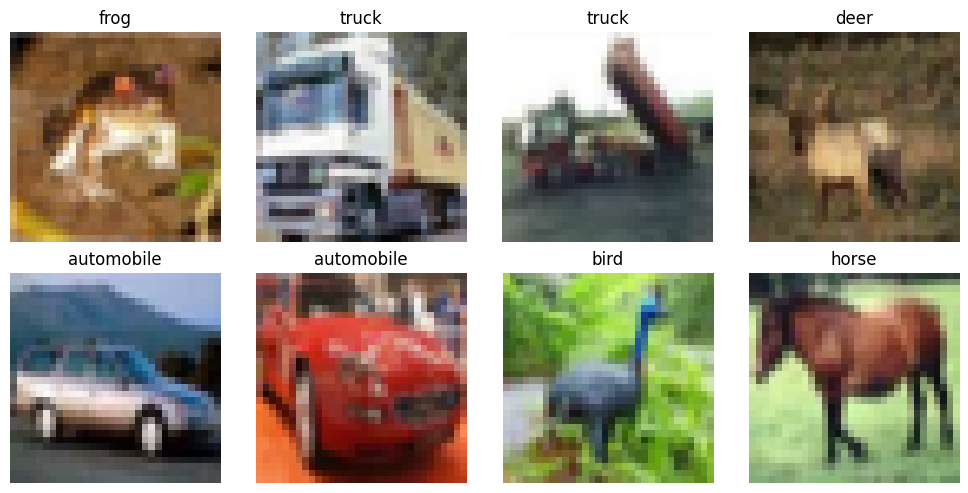

In [3]:
# Display a few example images.
# This helps us verify that the images loaded correctly and understand their size.

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

plt.figure(figsize=(10, 5))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[int(y_train[i][0])])
    plt.axis("off")
plt.tight_layout()
plt.show()


### What to notice

- Each image is **32 x 32 pixels**
- Each image has **3 colour channels** because it is RGB
- The labels are stored separately from the image pixels

In a mining context, each image could represent a sample photograph, drill core image, or conveyor snapshot.


## 3) Normalise the images


Pixel values in images usually range from **0 to 255**.

Neural networks often train better when inputs are scaled to a smaller range such as **0 to 1**.  
This makes optimisation more stable and is a standard preprocessing step in deep learning.


In [4]:
# Convert pixel values from the 0-255 range to the 0-1 range.
#
# Why this helps:
# - keeps the inputs on a smaller and more consistent scale
# - helps gradient-based training behave more smoothly
# - is a standard preprocessing step for image models

x_train = x_train / 255.0
x_test = x_test / 255.0

# Confirm the new value range for one image batch sample.
print("Minimum pixel value after normalisation:", x_train.min())
print("Maximum pixel value after normalisation:", x_train.max())


Minimum pixel value after normalisation: 0.0
Maximum pixel value after normalisation: 1.0


## 4) Build a simple CNN


A **Convolutional Neural Network (CNN)** is designed for image data.

### Mining interpretation of the layers

- **Conv2D** layers can learn patterns such as edges, boundaries, textures, and grain-like structures
- **MaxPooling2D** reduces the image size while keeping important patterns
- **Flatten** converts the image features into a 1D vector for classification
- **Dense** layers combine the learned visual information to predict a class


In [5]:
# Build a simple CNN using Keras Sequential.
#
# Layer by layer:
# 1. Conv2D learns small visual patterns from the input image
# 2. MaxPooling reduces image size and keeps stronger features
# 3. A second Conv2D + MaxPooling stack learns more complex patterns
# 4. Flatten converts the 2D feature maps into a 1D vector
# 5. Dense learns a compact hidden representation
# 6. Final Dense outputs probabilities for 10 classes

model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

# Show a summary so we can inspect the model architecture.
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

## 5) Compile the model


Before training, the model must be **compiled**.

This tells Keras:

- which optimisation method to use
- how prediction error should be measured
- which evaluation metrics to track


In [6]:
# Compile the model.
#
# optimizer='adam'
# - Adam is a widely used optimiser that usually works well for many deep learning tasks.
#
# loss='sparse_categorical_crossentropy'
# - This is suitable because the target labels are integer-coded classes.
#
# metrics=['accuracy']
# - Accuracy shows how often the predicted class matches the true class.

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


## 6) Train the model


Training means the CNN will look at many labelled images and gradually adjust its internal weights so it can recognise useful visual patterns.

### What an epoch means

One **epoch** means one complete pass through the training dataset.

In this lab, the training run is intentionally short so it can complete quickly in a workshop setting.


In [7]:
# Train the model.
#
# validation_data tells Keras to evaluate performance on the test set after each epoch.
# This helps us observe whether the model is improving on unseen data.
#
# epochs=3 is a short workshop-friendly setting.
# You can increase it later to explore how performance changes.

history = model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_data=(x_test, y_test)
)


Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 73s 46ms/step - accuracy: 0.4652 - loss: 1.4879 - val_accuracy: 0.5793 - val_loss: 1.1949
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 69s 44ms/step - accuracy: 0.5996 - loss: 1.1436 - val_accuracy: 0.6207 - val_loss: 1.0755
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 43ms/step - accuracy: 0.6432 - loss: 1.0208 - val_accuracy: 0.6443 - val_loss: 1.0179


## 7) Review the training history


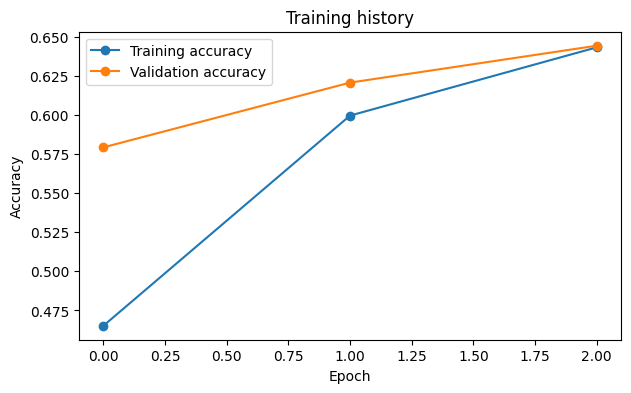

In [8]:
# Plot training and validation accuracy across epochs.
# This helps us see whether performance improved over time.

plt.figure(figsize=(7, 4))
plt.plot(history.history["accuracy"], marker="o", label="Training accuracy")
plt.plot(history.history["val_accuracy"], marker="o", label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training history")
plt.legend()
plt.show()


### Reflection prompt

After viewing the chart, think about these questions:

1. Did accuracy improve from one epoch to the next?
2. Is validation accuracy close to training accuracy, or noticeably lower?
3. What might that suggest about model learning and generalisation?


## 8) Evaluate model performance


In [9]:
# Evaluate the trained model on the test set.
#
# test_loss measures prediction error.
# test_acc measures the proportion of correct predictions.

test_loss, test_acc = model.evaluate(x_test, y_test)

print("Validation accuracy:", test_acc)
print("Validation loss:", test_loss)


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6443 - loss: 1.0179
Validation accuracy: 0.6442999839782715
Validation loss: 1.01785147190094


### Mining discussion

In a real mining image classification workflow, ask questions such as:

- Is this level of accuracy good enough for preliminary rock screening?
- What is the cost of misclassifying high-grade ore as low-grade?
- Should image predictions be used alone, or combined with geology, spectral, or assay data?


## 9) Make predictions on new images


In [10]:
# Make predictions for the first 5 test images.
#
# model.predict returns a probability distribution across all classes.
# np.argmax selects the class with the highest predicted probability.

for i in range(5):
    img = x_test[i]
    img_array = np.expand_dims(img, axis=0)

    prediction = model.predict(img_array, verbose=0)
    predicted_class = np.argmax(prediction)

    print(f"Image {i}: Predicted class = {predicted_class}, True class = {y_test[i][0]}")


Image 0: Predicted class = 3, True class = 3
Image 1: Predicted class = 8, True class = 8
Image 2: Predicted class = 8, True class = 8
Image 3: Predicted class = 0, True class = 0
Image 4: Predicted class = 4, True class = 6


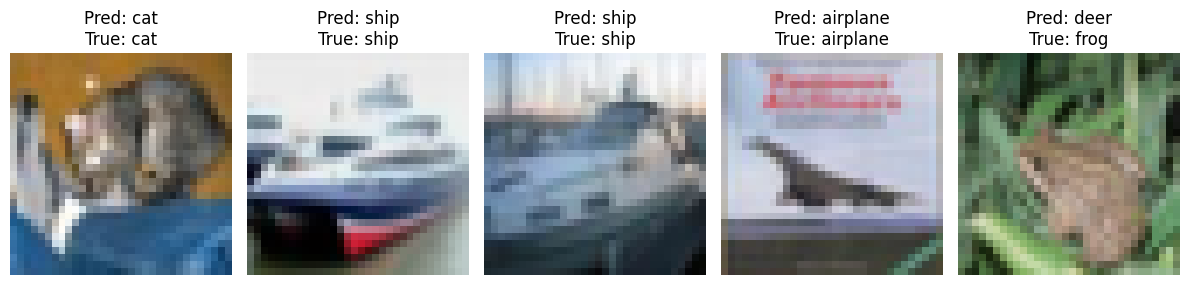

In [11]:
# Display the same 5 test images with their predicted and true labels.
# This makes the results easier to interpret visually.

plt.figure(figsize=(12, 3))
for i in range(5):
    img = x_test[i]
    img_array = np.expand_dims(img, axis=0)
    prediction = model.predict(img_array, verbose=0)
    predicted_class = np.argmax(prediction)

    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.title(f"Pred: {class_names[predicted_class]}\nTrue: {class_names[int(y_test[i][0])]}")
    plt.axis("off")

plt.tight_layout()
plt.show()


## 10) Guided practice tasks


Try the following activities after the core lab is working:

1. Increase the training epochs from **3** to **5** and compare the results.
2. Add another **Conv2D** layer and see whether validation accuracy changes.
3. Change the number of filters in the first layer from **32** to **16** or **64**.
4. Write down whether each change improved, reduced, or did not meaningfully change validation accuracy.

### Questions to answer

- Which model version performed best?
- Did extra training always improve validation performance?
- How would you explain the best result to a mining operations stakeholder?


## 11) Optional extension: mining interpretation


Imagine this model is being adapted for real mining photographs.

Write a short response to these questions in a new Markdown cell:

1. What kinds of rock image datasets would be needed to make this practical?
2. Why might image classification alone be insufficient for final ore grade decisions?
3. How could this kind of model support geologists, plant operators, or sorting workflows?
4. What risks exist if the model is wrong?


## Wrap-up

You have completed a computer vision lab that builds a simple CNN image classifier using TensorFlow / Keras.

### What you covered

- importing deep learning libraries
- loading an image dataset
- normalising image values
- building a simple CNN
- compiling and training the model
- evaluating on unseen test images
- making predictions on new images
- connecting image classification to mining applications

### Practical mining connection

The same workflow could be adapted for tasks such as:

- preliminary rock or material image classification
- conveyor stream image monitoring
- sample triage support
- anomaly flagging for geology review

In real mining deployments, image classification would usually be combined with domain expertise and other data sources rather than used in isolation.
